## Importing Libraries

In [1]:
# !pip install -q tensorflow-model-optimization

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  

import warnings
warnings.filterwarnings('ignore')
# import tensorflow_model_optimization as tfmot

import random
import time
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import glob
from PIL import Image
from pathlib import Path
import shutil

from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB1, MobileNetV3Small, VGG16, NASNetMobile
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_effnetb1
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.nasnet import preprocess_input as preprocess_nasnet
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as preprocess_mobilenetv3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.regularizers import l2

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from keras import utils
from keras.models import Model
from keras.callbacks import ModelCheckpoint


E0000 00:00:1768689619.095936      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768689619.166981      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768689619.745148      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768689619.745187      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768689619.745190      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768689619.745192      24 computation_placer.cc:177] computation placer already registered. Please check linka

## Seeding

In [3]:
seed = 18114
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS']= '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    
seed_everything(seed)

## CFG

In [4]:
class CFG:
    # Model & Training

    # Earlier versions of this notebook used 224, but as we aim for edge devices
    # (Mobile, Raspberry Pi) we will switch to smaller size to reduce inference time.
    
    # Recommended with MobileNetV3Small
    IMG_SIZE: int = 96
    WARMUP_EPOCHS: int = 10
    EPOCHS: int = 40
    BATCH_SIZE_PER_REPLICA: int = 64
    LR: float = 5e-3
    VERBOSE: int = 1
    UNFREEZE_RATIO: float = 0.35

    @staticmethod
    def preprocess_mobilenetv3(image):
        return tf.keras.applications.mobilenet_v3.preprocess_input(image)

    @staticmethod
    def preprocess_effnetb1(image):
        return tf.keras.applications.efficientnet.preprocess_input(image)

    @staticmethod
    def preprocess_vgg16(image):
        return tf.keras.applications.vgg16.preprocess_input(image)

    @staticmethod
    def preprocess_nasnet(image):
        return tf.keras.applications.nasnet.preprocess_input(image)
    
    PRE_PROCESS_EFFICIENTNET = preprocess_effnetb1
    PRE_PROCESS_VGG16 = preprocess_vgg16
    PRE_PROCESS_NASNET = preprocess_nasnet
    PRE_PROCESS_MOBILENETV3 = preprocess_mobilenetv3
    
    # Data
    NUM_CLASSES: int = 6
    TRAIN_FOLDER: str = '/kaggle/input/driver-inattention-detection-dataset/train'
    TEST_FOLDER: str = '/kaggle/input/driver-inattention-detection-dataset/test'
    VALID_FOLDER: str = '/kaggle/input/driver-inattention-detection-dataset/valid'

    DATA_PATH: str = "/kaggle/input/driver-inattention-detection-dataset/train"      
    SMAPLED_DATA_PATH: str = "/kaggle/working/sampled_dataset"    
    COMPRESSED_MODEL_PATH: str = "/kaggle/working/compressed_models"
    CLASSES_FILE_PATH: str = "/kaggle/input/driver-inattention-detection-dataset/train/_classes.txt"                     
    ANNOTATIONS_FILE_PATH: str = "/kaggle/input/driver-inattention-detection-dataset/train/_annotations.txt"            
    COMPRESSED_DYNAMIC_PATH: str = COMPRESSED_MODEL_PATH + "/model_dynamic.tflite"
    COMPRESSED_FLOAT16_PATH: str = COMPRESSED_MODEL_PATH + "/model_float16.tflite"
    COMPRESSED_INT8_PATH: str = COMPRESSED_MODEL_PATH + "/model_int8.tflite"
    SAMPLE_SIZE: int = 30   
    

    @property
    def TARGET_SIZE(self):
        return (self.IMG_SIZE, self.IMG_SIZE)

    @property
    def INPUT_SHAPE(self):
        return (self.IMG_SIZE, self.IMG_SIZE, 3)
    

cfg = CFG()

strategy = tf.distribute.MirroredStrategy()
cfg.BATCH_SIZE: int = cfg.BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

print(f'Devices Available: {strategy.num_replicas_in_sync}')
print(f'Image Size: {cfg.IMG_SIZE}, Target Size: {cfg.TARGET_SIZE}')
print(f'Batch Size: {cfg.BATCH_SIZE}')

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Devices Available: 2
Image Size: 96, Target Size: (96, 96)
Batch Size: 128


I0000 00:00:1768689633.984553      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768689633.988557      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## PreProcessing Dataset

In [5]:
preprocess_input = cfg.PRE_PROCESS_MOBILENETV3

def read_annotations(file_path):
    annotations = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            image_name = parts[0]
            try:
                bbox = list(map(int, parts[1].split(',')))
                if len(bbox) != 5:
                    continue
                annotations.append([image_name] + bbox)
            except ValueError:
                continue
    return pd.DataFrame(annotations, columns=['image_name', 'x_min', 'y_min', 'x_max', 'y_max', 'class_id'])

def preprocess_image(image_path, target_size):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = preprocess_input(image)
    return image


def one_hot_encode_labels(labels, num_classes):
    encoder = OneHotEncoder(sparse_output=False)
    labels = np.array(labels).reshape(-1, 1)
    one_hot_labels = encoder.fit_transform(labels)
    return one_hot_labels

def preprocess_dataset(annotations, folder_path, num_classes):
    images = []
    labels = []
    for _, row in annotations.iterrows():
        image_path = os.path.join(folder_path, row['image_name'])
        image = preprocess_image(image_path, cfg.TARGET_SIZE)
        if image is None:
            continue
        images.append(image)
        labels.append(row['class_id'])
    images = np.array(images)
    one_hot_labels = one_hot_encode_labels(labels, num_classes)
    return images, one_hot_labels
    

In [6]:
train_annotations = read_annotations(cfg.TRAIN_FOLDER + '/_annotations.txt')
test_annotations = read_annotations(cfg.TEST_FOLDER + '/_annotations.txt')
valid_annotations = read_annotations(cfg.VALID_FOLDER + '/_annotations.txt')


train_images, train_labels = preprocess_dataset(train_annotations, cfg.TRAIN_FOLDER, cfg.NUM_CLASSES)
test_images, test_labels = preprocess_dataset(test_annotations, cfg.TEST_FOLDER, cfg.NUM_CLASSES)
valid_images, valid_labels = preprocess_dataset(valid_annotations, cfg.VALID_FOLDER, cfg.NUM_CLASSES)

## Sampling data for Quantization

In [7]:
sampled_annots = train_annotations.groupby('class_id').head(30).reset_index(drop=True)
class_ids = sorted(sampled_annots['class_id'].unique())[:6]
sampled_annots = sampled_annots[sampled_annots['class_id'].isin(class_ids)]

sampled_images, sampled_labels = preprocess_dataset(sampled_annots,cfg.TRAIN_FOLDER, cfg.NUM_CLASSES)

In [8]:
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)

print("Valid images shape:", valid_images.shape)
print("Valid labels shape:", valid_labels.shape)

print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

print("Sampled images shape:", sampled_images.shape)
print("Sampled labels shape:", sampled_labels.shape)

Train images shape: (11948, 96, 96, 3)
Train labels shape: (11948, 6)
Valid images shape: (1922, 96, 96, 3)
Valid labels shape: (1922, 6)
Test images shape: (985, 96, 96, 3)
Test labels shape: (985, 6)
Sampled images shape: (180, 96, 96, 3)
Sampled labels shape: (180, 6)


In [9]:
(x_train, y_train), (x_val, y_val) = (train_images, train_labels), (valid_images, valid_labels)

class_weights = compute_class_weight('balanced', 
                                    classes=np.unique(train_annotations['class_id']), 
                                    y=train_annotations['class_id'])
class_weight_dict = dict(enumerate(class_weights))

## Parallel Dataset creation

In [10]:
def create_datasets(x_train, y_train, x_val, y_val, batch_size):
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(len(x_train), seed=seed)
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
    
    return train_dataset, val_dataset

## Building the model

In [11]:
with strategy.scope():

    train_dataset, val_dataset = create_datasets(
        x_train, y_train, x_val, y_val, cfg.BATCH_SIZE)

    optimizer = Adam(learning_rate=cfg.LR)
    
    #Callbacks definition
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6)
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
    
    CALL_BACKS = [reduce_lr]

    
    inputs = tf.keras.Input(shape=cfg.INPUT_SHAPE)

    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.015)(x)
    x = tf.keras.layers.RandomBrightness(0.2)(x) 
    x = tf.keras.layers.RandomContrast(0.2)(x) 
    
    base_model = MobileNetV3Small(weights='imagenet',
                                include_top=False,
                                input_shape=cfg.INPUT_SHAPE)
    base_model.trainable = False
    x = base_model(x)
    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization(momentum=0.99, epsilon=1e-3)(x)
    x = Dropout(0.3)(x)
    
    output = Dense(cfg.NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=output)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 96, 96, 3)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 96, 96, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 3, 3, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,262 (3.87 MB)

 Trainable params: 74,886 (292.52 KB)

 Non-trainable params: 939,376 (3.58 MB)

## Warmingup the model

In [13]:
warmup_history = model.fit(train_dataset, 
                    epochs=cfg.WARMUP_EPOCHS,
                    validation_data=val_dataset,
                    callbacks=CALL_BACKS,
                    class_weight=class_weight_dict,
                    verbose=cfg.VERBOSE)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1768689815.320690      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1768689816.376029      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3424 - loss: 1.8886INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.3432 - loss: 1.8856 - val_accuracy: 0.5406 - val_loss: 1.3667 - learning_rate: 0.0050
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4987 - loss: 1.3305 - val_accuracy: 0.5411 - val_loss: 1.3106 - learning_rate: 0.0050
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5315 - loss: 1.2334 - val_accuracy: 0.6457 - val_loss: 1.1510 - learning_rate: 0.0050
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5572 - loss: 1.2063 - val_accuracy: 0.6634 - val_loss: 1.0914 - learning_rate: 0.0050
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5572 - loss: 1.1936 - val_accuracy: 0.5593 - val_loss: 1.2452 - learning_rate: 0.0050
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 2

## Model evaluation

In [14]:
def evaluate_histories(history1, history2):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'] + history2.history['accuracy'])
    plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history1.history['loss'] + history2.history['loss'])
    plt.plot(history1.history['val_loss'] + history2.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
    
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")


def evaluate_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
    
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

## Warmup results

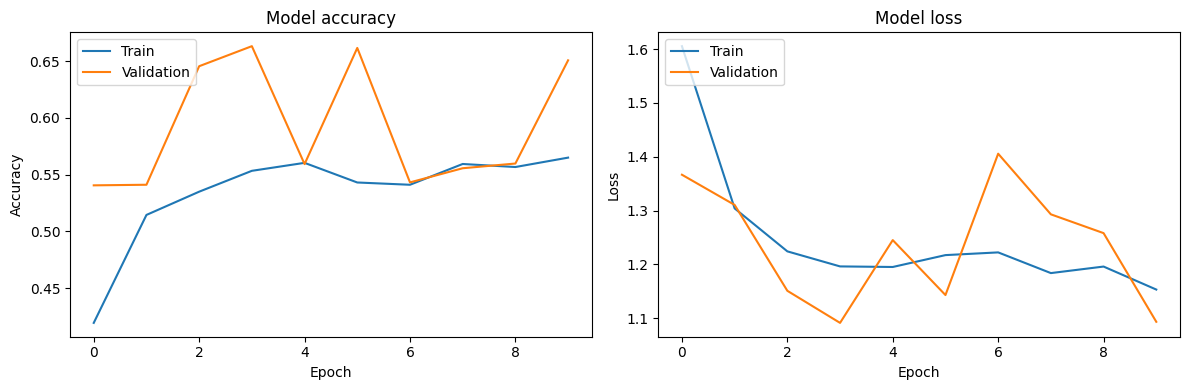

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6377 - loss: 1.1873
Test accuracy: 0.6538, Test loss: 1.1503


In [15]:
evaluate_history(warmup_history)

## Fine Tuning

In [16]:
unfrozen_layers = int(len(base_model.layers) * (1 - cfg.UNFREEZE_RATIO))
unfrozen_layers

102

In [17]:
with strategy.scope():
    base_model.trainable = True
    for layer in base_model.layers[:unfrozen_layers]:
        layer.trainable = False


    fine_tune_steps = (cfg.EPOCHS) * (len(x_train) // cfg.BATCH_SIZE)
    
    fine_tune_schedule = CosineDecay(
        initial_learning_rate=cfg.LR*0.9,
        decay_steps=fine_tune_steps,
        alpha=0.01
    )
    optimizer = Adam(learning_rate=fine_tune_schedule)

    CALL_BACKS = []
    
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


tuned_history = model.fit(train_dataset, 
                    epochs=cfg.EPOCHS,
                    validation_data=val_dataset,
                    callbacks=CALL_BACKS,
                    class_weight=class_weight_dict,
                    verbose=cfg.VERBOSE)

Epoch 1/40
INFO:tensorflow:Collective all_reduce tensors: 53 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.5683 - loss: 1.1828 - val_accuracy: 0.4537 - val_loss: 8.6417
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7741 - loss: 0.7028 - val_accuracy: 0.6894 - val_loss: 2.7534
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8116 - loss: 0.5627 - val_accuracy: 0.4735 - val_loss: 52.0893
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8338 - loss: 0.5314 - val_accuracy: 0.6285 - val_loss: 3.8573
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8548 - loss: 0.4392 - val_accuracy: 0.4339 - val_loss: 5.9237
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8570 - loss: 0.3985 - val_accuracy: 0.4547 - val_loss: 7.6460
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8575 - los

## Final results

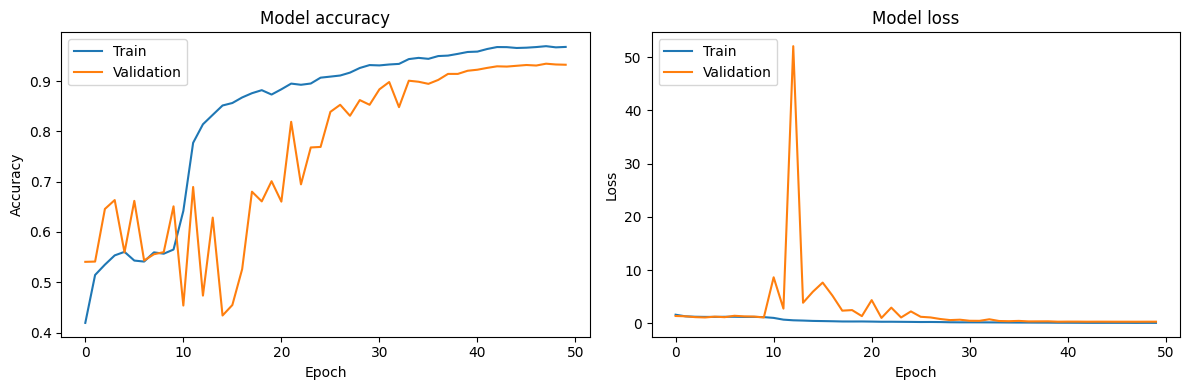

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9124 - loss: 0.3198
Test accuracy: 0.9076, Test loss: 0.3466


In [18]:
evaluate_histories(warmup_history, tuned_history)

## Saving the final model

In [19]:
model.save('model.keras')

## Quantization

In [20]:
def prepare_quantization_dataset_float32():
    
    print("🔧 Preparing float32 [0, 255] quantization dataset...")
    
    annotations = read_annotations(cfg.ANNOTATIONS_FILE_PATH)
    sampled_annots = annotations.groupby('class_id').head(30)
    
    quantization_images = []
    
    for _, row in sampled_annots.iterrows():
        image_path = os.path.join(cfg.TRAIN_FOLDER, row['image_name'])
        
        # Read and preprocess image
        image = cv2.imread(image_path)
        if image is None:
            continue
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, cfg.TARGET_SIZE)
        
        # Convert to float32 [0, 255] - what MobileNetV3 Rescaling expects
        quantization_images.append(image.astype(np.float32))
    
    quantization_images = np.array(quantization_images)
    
    print(f"✅ Prepared {len(quantization_images)} float32 [0, 255] images")
    print(f"   Range: [{quantization_images.min():.1f}, {quantization_images.max():.1f}]")
    print(f"   Dtype: {quantization_images.dtype}")
    
    return quantization_images

In [21]:
def representative_dataset_float32():
    quant_imgs = prepare_quantization_dataset_float32()
    
    for i in range(len(quant_imgs)):
        img = np.expand_dims(quant_imgs[i], axis=0).astype(np.float32)
        yield [img]

In [22]:
def quantize_dynamic():
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_float32
    
    tflite_model = converter.convert()
    
    with open(cfg.COMPRESSED_DYNAMIC_PATH, 'wb') as f:
        f.write(tflite_model)
    
    print(f"✅ Dynamic range model saved to: {cfg.COMPRESSED_DYNAMIC_PATH}")
    print(f"📏 Model size: {len(tflite_model) / 1024:.1f} KB")
    
    return tflite_model

In [23]:
def quantize_float16():
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    converter.representative_dataset = representative_dataset_float32

    tflite_model = converter.convert()
    
    with open(cfg.COMPRESSED_FLOAT16_PATH, 'wb') as f:
        f.write(tflite_model)
    
    print(f"✅ Float16 model saved to: {cfg.COMPRESSED_FLOAT16_PATH}")
    print(f"📏 Model size: {len(tflite_model) / 1024:.1f} KB")
    
    return tflite_model

In [24]:
def quantize_int8():
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_float32
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.float32  # Input: float32 [0, 255]
    converter.inference_output_type = tf.float32  # Output: float32 probabilities
    
    tflite_model = converter.convert()
    
    with open(cfg.COMPRESSED_INT8_PATH, 'wb') as f:
        f.write(tflite_model)
    
    print(f"✅ INT8 model saved to: {cfg.COMPRESSED_INT8_PATH}")
    print(f"📏 Model size: {len(tflite_model) / 1024:.1f} KB")
    print("⚠ Note: INT8 uses float32 input/output with internally quantized weights")
    
    return tflite_model

In [25]:
def quantize_all_models():
    results = {}
    
    os.makedirs(os.path.dirname(cfg.COMPRESSED_DYNAMIC_PATH), exist_ok=True)
    
    print("\n1. Dynamic Range Quantization:")
    try:
        dynamic_model = quantize_dynamic()
        results['dynamic'] = {'success': True, 'size_kb': len(dynamic_model) / 1024}
    except Exception as e:
        print(f"❌ Failed: {e}")
        results['dynamic'] = {'success': False, 'error': str(e)}
    
    print("\n2. Float16 Quantization:")
    try:
        float16_model = quantize_float16()
        results['float16'] = {'success': True,'size_kb': len(float16_model) / 1024}
    except Exception as e:
        print(f"❌ Failed: {e}")
        results['float16'] = {'success': False, 'error': str(e)}
    
    print("\n3. INT8 Quantization:")
    try:
        int8_model = quantize_int8()
        results['int8'] = {'success': True,'size_kb': len(int8_model) / 1024}
    except Exception as e:
        print(f"❌ Failed: {e}")
        results['int8'] = {'success': False, 'error': str(e)}
    
    # Summary
    print(f"\n{'='*60}")
    print("QUANTIZATION SUMMARY")
    print(f"{'='*60}")
    
    for model_type, result in results.items():
        if result['success']:
            print(f"{model_type.upper():10} → ✅ Success | Size: {result['size_kb']:.1f} KB")
        else:
            print(f"{model_type.upper():10} → ❌ Failed | Error: {result['error'][:50]}...")
    
    return results

In [26]:
def test_quantized_model(model_path, model_name=""):
    if not os.path.exists(model_path):
        print(f"❌ Model not found: {model_path}")
        return None
    
    print(f"\n{'='*60}")
    print(f"Testing: {model_name if model_name else os.path.basename(model_path)}")
    print(f"Input: float32 [0, 255] (MobileNetV3 Rescaling)")
    print(f"{'='*60}")
    
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    print(f"📊 Model Details:")
    print(f"  Input: dtype={input_details['dtype']}, shape={input_details['shape']}")
    print(f"  Output: dtype={output_details['dtype']}, shape={output_details['shape']}")
    
    # Test configuration
    samples = min(1000, len(test_images))
    correct = 0
    total_time = 0
    
    print(f"\n🧪 Testing {samples} samples...")
    
    for i in range(samples):
        img = test_images[i:i+1].astype(np.float32)
        
        # Prepare input based on model's expected dtype
        if input_details['dtype'] == np.float32:
            img_prepared = img
        elif input_details['dtype'] == np.float16:
            img_prepared = img.astype(np.float16)
        elif input_details['dtype'] == np.uint8:
            # Shouldn't happen for our models, but handle just in case
            img_prepared = img.astype(np.uint8)
        else:
            img_prepared = img.astype(input_details['dtype'])
        
        # Ensure correct shape
        if img_prepared.shape != tuple(input_details['shape']):
            if input_details['shape'][0] == 1:
                img_prepared = img_prepared.reshape(input_details['shape'])
            elif input_details['shape'][0] == -1:
                # Dynamic batch size
                pass
        
        # Time inference
        start = time.perf_counter()
        interpreter.set_tensor(input_details['index'], img_prepared)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details['index'])
        end = time.perf_counter()
        
        total_time += (end - start)
        
        # Get prediction
        if output.shape[0] == 1:
            pred = np.argmax(output[0])
        else:
            pred = np.argmax(output)
        
        true = np.argmax(test_labels[i])
        
        if pred == true:
            correct += 1
    
    # Calculate metrics
    accuracy = correct / samples
    avg_time_ms = (total_time / samples) * 1000
    fps = 1000 / avg_time_ms if avg_time_ms > 0 else 0
    
    print(f"\n📈 Results:")
    print(f"  Accuracy: {accuracy:.3f} ({correct}/{samples})")
    print(f"  Latency: {avg_time_ms:.1f}ms per image")
    print(f"  Throughput: {fps:.1f} FPS")
    
    return {'accuracy': accuracy,'latency_ms': avg_time_ms,'fps': fps,'samples': samples}

In [27]:
def test_keras_baseline():
    
    print(f"\n{'='*60}")
    print("KERAS MODEL BASELINE")
    print(f"{'='*60}")
    
    samples = min(200, len(test_images))
    correct = 0
    total_time = 0
    
    for i in range(samples):
        img = test_images[i:i+1].astype(np.float32)
        
        start = time.perf_counter()
        prediction = model.predict(img, verbose=0)
        end = time.perf_counter()
        
        total_time += (end - start)
        
        pred = np.argmax(prediction[0])
        true = np.argmax(test_labels[i])
        
        if pred == true:
            correct += 1
    
    accuracy = correct / samples
    avg_time_ms = (total_time / samples) * 1000
    fps = 1000 / avg_time_ms if avg_time_ms > 0 else 0
    
    print(f"📈 Results:")
    print(f"  Accuracy: {accuracy:.3f} ({correct}/{samples})")
    print(f"  Latency: {avg_time_ms:.1f}ms per image")
    print(f"  Throughput: {fps:.1f} FPS")
    
    return {'accuracy': accuracy,'latency_ms': avg_time_ms,'fps': fps,'samples': samples}

In [28]:
def test_all_compressed_models():
    
    models_to_test = [
        ("Keras Baseline", None), 
        #("Dynamic Range", cfg.COMPRESSED_DYNAMIC_PATH),
        ("Float16", cfg.COMPRESSED_FLOAT16_PATH)
        #("INT8", cfg.COMPRESSED_INT8_PATH),
    ]
    
    results = {}
    
    # Test Keras baseline first
    print("\n1. Keras Baseline Model:")
    keras_results = test_keras_baseline()
    results['keras'] = keras_results
    
    # Test each compressed model
    for name, path in models_to_test[1:]:  # Skip Keras baseline
        if path is None:
            continue
            
        if not os.path.exists(path):
            print(f"\n❌ {name}: Model not found at {path}")
            print("   Run quantization first using quantize_all_models()")
            results[name.lower().replace(' ', '_')] = None
            continue
        
        print(f"\n{name}:")
        model_results = test_quantized_model(path, name)
        results[name.lower().replace(' ', '_')] = model_results
    
    # Summary table
    print(f"\n{'='*60}")
    print("SUMMARY COMPARISON")
    print(f"{'='*60}")
    print(f"{'Model':20} | {'Accuracy':10} | {'Latency':10} | {'FPS':10} | {'Size':10}")
    print(f"{'-'*20} | {'-'*10} | {'-'*10} | {'-'*10} | {'-'*10}")
    
    # Get model sizes
    model_sizes = {}
    for name, path in models_to_test[1:]:
        if path and os.path.exists(path):
            size_kb = os.path.getsize(path) / 1024
            model_sizes[name.lower().replace(' ', '_')] = size_kb
    
    # Print results
    for model_name, result in results.items():
        if result is None:
            print(f"{model_name:20} | {'N/A':10} | {'N/A':10} | {'N/A':10} | {'N/A':10}")
        else:
            size_str = f"{model_sizes.get(model_name, 'N/A'):.1f}KB" if model_name in model_sizes else "N/A"
            print(f"{model_name:20} | {result['accuracy']:10.3f} | "
                  f"{result['latency_ms']:10.1f}ms | {result['fps']:10.1f} | {size_str:10}")
    
    # Calculate accuracy drops
    print(f"\n{'='*60}")
    print("ACCURACY DROP vs KERAS BASELINE")
    print(f"{'='*60}")
    
    keras_acc = results['keras']['accuracy']
    for model_name, result in results.items():
        if model_name != 'keras' and result is not None:
            accuracy_drop = keras_acc - result['accuracy']
            print(f"{model_name:20} → Drop: {accuracy_drop:+.3f} "
                  f"({result['accuracy']/keras_acc*100:.1f}% of baseline)")
    
    return results

## Applying Quantization

In [29]:
quantize_all_models()


1. Dynamic Range Quantization:
INFO:tensorflow:Assets written to: /tmp/tmp7m02gt6s/assets


INFO:tensorflow:Assets written to: /tmp/tmp7m02gt6s/assets


Saved artifact at '/tmp/tmp7m02gt6s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  136311467827152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467830032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467828496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467829072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467827344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467831952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467833104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467833872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467833488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467832336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467834064:

W0000 00:00:1768690070.240207      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1768690070.240249      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1768690070.366058      24 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


🔧 Preparing float32 [0, 255] quantization dataset...
✅ Prepared 180 float32 [0, 255] images
   Range: [0.0, 255.0]
   Dtype: float32


...

Saved artifact at '/tmp/tmp1hs7jubx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  136311467827152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467830032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467828496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467829072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467827344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467831952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467833104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467833872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467833488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467832336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136311467834064:

W0000 00:00:1768690088.125236      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1768690088.125264      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


🔧 Preparing float32 [0, 255] quantization dataset...
✅ Prepared 180 float32 [0, 255] images
   Range: [0.0, 255.0]
   Dtype: float32
✅ INT8 model saved to: /kaggle/working/compressed_models/model_int8.tflite
📏 Model size: 1265.3 KB
⚠ Note: INT8 uses float32 input/output with internally quantized weights

QUANTIZATION SUMMARY
DYNAMIC    → ✅ Success | Size: 1265.3 KB
FLOAT16    → ✅ Success | Size: 2004.0 KB
INT8       → ✅ Success | Size: 1265.3 KB


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


{'dynamic': {'success': True, 'size_kb': 1265.3125},
 'float16': {'success': True, 'size_kb': 2003.9765625},
 'int8': {'success': True, 'size_kb': 1265.3125}}

## Comparision

In [30]:
test_all_compressed_models()


1. Keras Baseline Model:

KERAS MODEL BASELINE


W0000 00:00:1768690094.722704      24 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Conv2D" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NCHW" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "SAME" } } attr { key: "strides" value { list { i: 1 i: 1 i: 2 i: 2 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 3 } dim { size: 96 } dim { size: 96 } } } inputs { dtype: DT_FLOAT shape { dim { size: 3 } dim { size: 3 } dim { size: 3 } dim { size: 16 } } } device { type: "GPU" vendor: "NVIDIA" model: "Tesla T4" frequency: 1590 num_cores: 40 environment { key: "architecture" value: "7.5" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90300" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 4194304 shared_memory_size_per_multipro

📈 Results:
  Accuracy: 0.900 (180/200)
  Latency: 297.3ms per image
  Throughput: 3.4 FPS

Float16:

Testing: Float16
Input: float32 [0, 255] (MobileNetV3 Rescaling)
📊 Model Details:
  Input: dtype=<class 'numpy.float32'>, shape=[ 1 96 96  3]
  Output: dtype=<class 'numpy.float32'>, shape=[1 6]

🧪 Testing 985 samples...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



📈 Results:
  Accuracy: 0.908 (894/985)
  Latency: 0.6ms per image
  Throughput: 1782.8 FPS

SUMMARY COMPARISON
Model                | Accuracy   | Latency    | FPS        | Size      
-------------------- | ---------- | ---------- | ---------- | ----------
keras                |      0.900 |      297.3ms |        3.4 | N/A       
float16              |      0.908 |        0.6ms |     1782.8 | 2004.0KB  

ACCURACY DROP vs KERAS BASELINE
float16              → Drop: -0.008 (100.8% of baseline)


{'keras': {'accuracy': 0.9,
  'latency_ms': 297.31155924499376,
  'fps': 3.363475010993332,
  'samples': 200},
 'float16': {'accuracy': 0.9076142131979695,
  'latency_ms': 0.5609204071107587,
  'fps': 1782.7841300174716,
  'samples': 985}}